<a href="https://colab.research.google.com/github/YefridC09/ST-554_Big_data_analysis/blob/main/HW5_Yefrid__Cordoba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 5 - ST-554**

# Author: **Yefrid Cordoba**

## Part I - Concepts

### 1

In the manufacturing of paper, there are sensors across the paper machine that register data over time, having a big **Volume** of data that continuously is streamed (**Velocity**), this data can be of different types like temperature, flows, pressures, refining energy, basis weight, moisture, strength, speed, etc (**Variety**). As there is always variability in phenomena that cannot be controlled during the process (Heterogeneity of the fibers, equipment malfunction, etc.), the uncertainty needs to be considered in this type of data(**Veracity**). Analyzing data from paper machine operations can be used to predict important product parameters, such as paper strength or productivity, which will help us avoid downtime and product rejections due to quality compliance (**Value**).

### 2

First it is necessary to load the module `sqlite3` and make the connection to the .sqlite file (the file needs to be uploaded to the main folder)

In [12]:
#Import the modules
import sqlite3
import pandas as pd

#Connectin to the .sqlite file
MLB = sqlite3.connect("lahman_1871-2022.sqlite")

I will create a helper function for the querys execution.

In [ ]:
def execute_query(connection, query):
    cursor = connection.cursor()
    try:
        cursor.execute(query)
        print("Query executed successfully")
        #connection.commit()
    except sqlite3.Error as e:
        print(f"The error '{e}' occurred")
    cursor.close()

For the creation of a new table, first it is necessary to create a cursor, generate the SQL, execute the SQL code, and finally close the cursor.

A new table will be neccesary when a new set of related statistics needs to be added to the database.

In [ ]:
#Write the SQL to create a new table that contains the points for each game for both of the team
nt = """
    CREATE TABLE IF NOT EXISTS recent_final (
        LA_dodgers INT,
        T_BlueJays INT);
"""
#execute the SQL code
execute_query(MLB,nt)

Query executed successfully


Checking if the code worked

In [ ]:
pd.read_sql('''
        SELECT *
        FROM recent_final;
        ''', MLB)

,LA_dodgers,T_BlueJays


Now it is necessary to create a query that will add the rows to the table, the code is executed, and the table is shown.

In [ ]:
#Create the query to insert the data
c_rows = """
        INSERT INTO recent_final (LA_dodgers, T_BlueJays)
        VALUES
            (4, 11),
            (5, 1),
            (6, 5),
            (2, 6),
            (1, 6),
            (3, 1)
"""

#Executing the query
execute_query(MLB, c_rows)

#Showing the table
pd.read_sql('''
        SELECT *
        FROM recent_final;
        ''', MLB)

Query executed successfully


,LA_dodgers,T_BlueJays
0,4,11
1,5,1
2,6,5
3,2,6
4,1,6
5,3,1


In [ ]:
create_row = """
       INSERT INTO
           recent_final (LA_dodgers)
       VALUES
           (5);
"""

execute_query(MLB, create_row)

Query executed successfully


In [ ]:
#Showing the table
pd.read_sql('''
        SELECT *
        FROM recent_final;
        ''', MLB)

,LA_dodgers,T_BlueJays
0,4,11.0
1,5,1.0
2,6,5.0
3,2,6.0
4,1,6.0
5,3,1.0
6,5,NaN


Now we update the data with the missing value.
As data is coming in over time to the database (games that are being played), the data needs to be constantly updated by adding rows to the database.

In [ ]:
mod_row = """
    UPDATE recent_final
    SET T_BlueJays = 4
    WHERE (T_BlueJays is null);
"""

execute_query(MLB, mod_row)

#Showing the table
pd.read_sql('''
        SELECT *
        FROM recent_final;
        ''', MLB)

Query executed successfully


,LA_dodgers,T_BlueJays
0,4,11
1,5,1
2,6,5
3,2,6
4,1,6
5,3,1
6,5,4


Now we delete the rows where the points are greater than 6

In [ ]:
del_row = """
    DELETE FROM recent_final
    WHERE LA_dodgers > 6 OR T_BlueJays > 6
    """

execute_query(MLB, del_row)

#Showing the table
pd.read_sql('''
        SELECT *
        FROM recent_final;
        ''', MLB)

Query executed successfully


,LA_dodgers,T_BlueJays
0,5,1
1,6,5
2,2,6
3,1,6
4,3,1
5,5,4


Finally, the created table will be removed from the database

In [ ]:
d_table = """
    DROP TABLE recent_final;
"""

execute_query(MLB, d_table)

Query executed successfully


In order to read the data we get the schema.
Reading the data is one of the most important tasks for us, as we will need the information from the tables to perform the analysis.

In [ ]:
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''

# creating a dataframe with the schema
schema_MLB = pd.read_sql(get_schema, MLB)
schema_MLB

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


The data is read using `pd.read_sql()`

In [ ]:
#Reading the data from table AllstarFull
pd.read_sql('SELECT * FROM AllstarFull', MLB)

,playerID,yearID,gameNum,gameID,teamID,lgID,GP,startingPos
0,gomezle01,1933,0,ALS193307060,NYA,AL,1,1
1,ferreri01,1933,0,ALS193307060,BOS,AL,1,2
2,gehrilo01,1933,0,ALS193307060,NYA,AL,1,3
3,gehrich01,1933,0,ALS193307060,DET,AL,1,4
4,dykesji01,1933,0,ALS193307060,CHA,AL,1,5
...,...,...,...,...,...,...,...,...
5511,rileyau01,2022,0,NLS202207190,ATL,NL,1,None
5512,schwaky01,2022,0,NLS202207190,PHI,NL,1,None
5513,sotoju01,2022,0,NLS202207190,WAS,NL,1,None
5514,swansda01,2022,0,NLS202207190,ATL,NL,1,None


### 3

The `HAVING` clause is important when a condition stated after this clause needs to be meet when using the `GROUP BY`. It is an optional clause for the `SELECT` statement. `HAVING` always needs to be used after `GROUP BY`. This clause can be used to make SQL joins with conditional filtering.

## Part II - Simulation of a sampling distribution

### 4

The code from the HW5 document

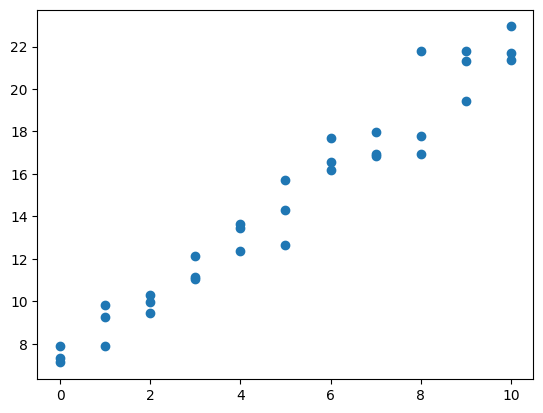

In [25]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
import sklearn as sk
from numpy.random import default_rng
from scipy.stats import percentileofscore

#create a random number generator
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()

As an example of what we have to repeat 5000 times, the next block will generate the slope for the above data.

In [3]:
reg = sk.linear_model.LinearRegression()
reg.fit(x.reshape(-1,1), y)
print(reg.intercept_, reg.coef_)

7.259043801350283 [1.47450564]


Now we have to repeat the process 5000 times using a for loop

In [8]:
#First an object is created to store the slopes
slopes = []

#The loop will iterate and generate 5000 slopes for the data
for i in range(5000):
    beta_0 = 7
    beta_1 = 1.5
    # get three 'values' of x at each integer from 0 to 10.
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
    n = 33
    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    reg = sk.linear_model.LinearRegression()
    reg.fit(x.reshape(-1,1), y)
    #print(reg.intercept_, reg.coef_)
    slopes.append(reg.coef_[0])
print(slopes)

[np.float64(1.4635694700115702), np.float64(1.5240143668058495), np.float64(1.4765562551132707), np.float64(1.4352969628331635), np.float64(1.4871769908498838), np.float64(1.5595635919545354), np.float64(1.457936089632674), np.float64(1.5239694267549453), np.float64(1.554883718941858), np.float64(1.518419722536912), np.float64(1.546559120599839), np.float64(1.5266012560605748), np.float64(1.540048618661469), np.float64(1.4580827010246182), np.float64(1.4568799818500255), np.float64(1.4478105927934657), np.float64(1.4887796835020597), np.float64(1.4510179291282013), np.float64(1.4332577353743645), np.float64(1.5215306123800774), np.float64(1.4182480245642715), np.float64(1.520626213067568), np.float64(1.5652126906009356), np.float64(1.5187222330077887), np.float64(1.5309499951346572), np.float64(1.506333636441774), np.float64(1.501433818126075), np.float64(1.4620727270852478), np.float64(1.4232483865044854), np.float64(1.4764909062437197), np.float64(1.4050938548128533), np.float64(1.55

The next step is to generate a histogram of the slopes

<Axes: ylabel='Frequency'>

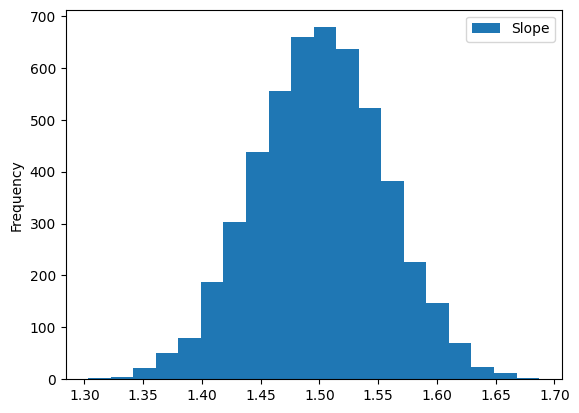

In [16]:
#First we turn into a data frame to use .plot
slopes = pd.DataFrame(slopes, columns = ['Slope'])
slopes.plot.hist(bins = 20)

The histogram above contains the randomly generated slopes with a mean value of 1.5. Now, we need to evaluate the probability of observing a sample slope larger than 1.65.

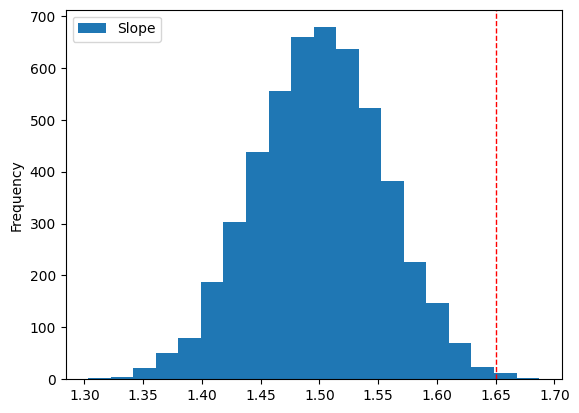

In [23]:
slopes = pd.DataFrame(slopes, columns = ['Slope'])
slopes.plot.hist(bins = 20)
plt.axvline(1.65, color='red', linestyle='dashed', linewidth=1)

It is necessary to calculate from the generated slopes the percentage of data that are larger than 1.65(to the right of the red dashed line), this will be the probability of observing sa sample slope larger than 1.65.

The function `percentileofscore` from the `scipy` module will calculate this value; however, defining the `kind = 'weak' will estimate the values that are lower than or equal to the specified value. We need to calculate the 1-percentile to find the value we are looking for.

In [31]:
#Calculate the proportion of simulated values that are larger than 1.65
percentile_rank = 1 - (percentileofscore(list(slopes['Slope']), 1.65, kind='weak')/100)
percentile_rank

np.float64(0.0028000000000000247)

Assuming that the true mean slope is 1.5, the probability of getting a sample slope that is larger of 1.65 is about 0.28%.

This is important for us to determine and conclude whether a calculated slope is close to an assumed true value after setting an especified $\alpha$ value from which we are going to do the hypothesis test.

## Part III - Big data examples & rare events

### 5